<div align="center">

# 3_1_4_var_cuantitativas

### July 13, 2026

<br>

<img src="img/logoitqv1.jpg" width="650">

<br><br>

</div>

# 0.1 PAO26-26 - Variables cuantitativas

<div align="center">

<img src="img/python_logo.png" width="550">

</div>

<div align="left">

### Eric Campoverde

<a href="https://github.com/EricJordy/MachineLearning_teoria">Repositorio Git</a>

</div>

<hr style="height:3px;border:none;background:#b30000;">



In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
-28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)

[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [2]:
# Medidas de tendencia central
from scipy import stats

media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [3]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt
Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC
print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)


RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


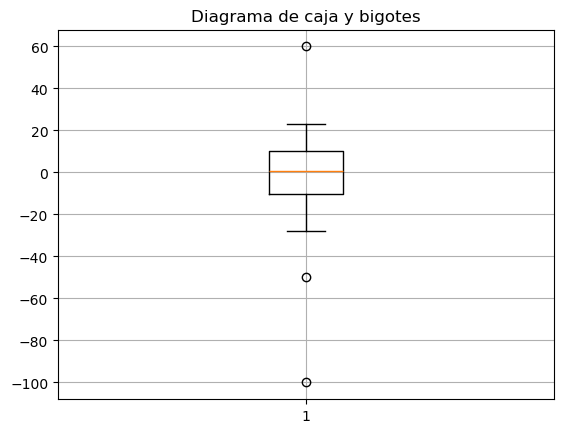

In [4]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers

plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()


In [6]:
# Medidas de dispersión

desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [7]:
# Medidas de distribución

asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html

print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [8]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint

iris = datasets.load_iris()
pprint(iris)

X = iris.data
y = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???

longitud_petalo = X[:, 2] # petal length (cm) es la 3ra columna
asimetria_petalo = stats.skew(longitud_petalo)

print('Asimetría (longitud del pétalo):', np.round(asimetria_petalo, 4))

if asimetria_petalo > 0:
    print('La variable presenta una asimetría positiva (sesgo hacia la derecha).')
elif asimetria_petalo < 0:
    print('La variable presenta una asimetría negativa (sesgo hacia la izquierda).')
else:
    print('La variable es simétrica.')

print()
# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
#???
ancho_sepalo = X[:, 1] # sepal width (cm) es la 2da columna
curtosis_sepalo = stats.kurtosis(ancho_sepalo, fisher=True)
print('Curtosis (ancho del sépalo):', np.round(curtosis_sepalo, 4))

if curtosis_sepalo > 0:
    print('La distribución es leptocúrtica.')
elif curtosis_sepalo < 0:
    print('La distribución es platicúrtica.')
else:
    print('La distribución es mesocúrtica.')


{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

In [9]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (`plt.errorbar`)

import pandas as pd

# Convertimos a DataFrame para facilitar el agrupamiento
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['target'] = y
df_iris['especie'] = df_iris['target'].map(dict(enumerate(iris.target_names)))

# Calculamos media y desviación típica por especie
medias = df_iris.groupby('especie')[iris.feature_names].mean()
desviaciones = df_iris.groupby('especie')[iris.feature_names].std()

print(medias)
print(desviaciones)

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
especie                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
especie                       
setosa                 0.246  
versicolor             1.326  
virginica              2.026  
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
especie                                                              
setosa               0.352490          0.379064           0.173664   
versicolor           0.516171          0.313798           0.469911   
virginica            0.635880          0.322497           0.551895   

            petal width (cm)  
especie                       
setosa              0.105386  
versicolor          0.197753  
virginica          